In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
df = pd.read_csv("train.csv")
df.head()
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np
import matplotlib.pyplot as plt
print("Shape of Dataset:", df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    format="mixed"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True,
    format="mixed"
)
print(df[["Order Date", "Ship Date"]].dtypes)
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)
df.head()
print("Missing Values\n")

print(df.isnull().sum())
duplicates = df.duplicated().sum()

print("Duplicate Rows =", duplicates)
print(df.info())
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()
weekly_sales = (
    df.resample("W", on="Order Date")["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()
monthly_sales = (
    df.resample("ME", on="Order Date")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

Shape of Dataset: (9800, 18)

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

Data Types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object
Missing Values

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


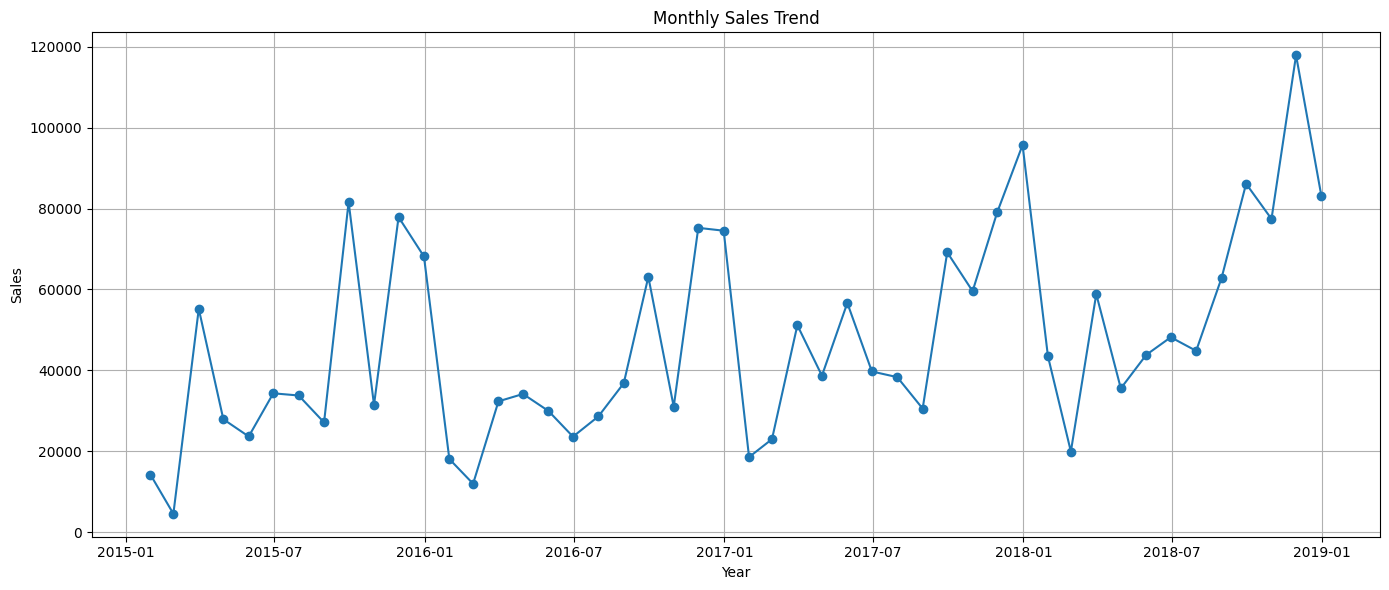

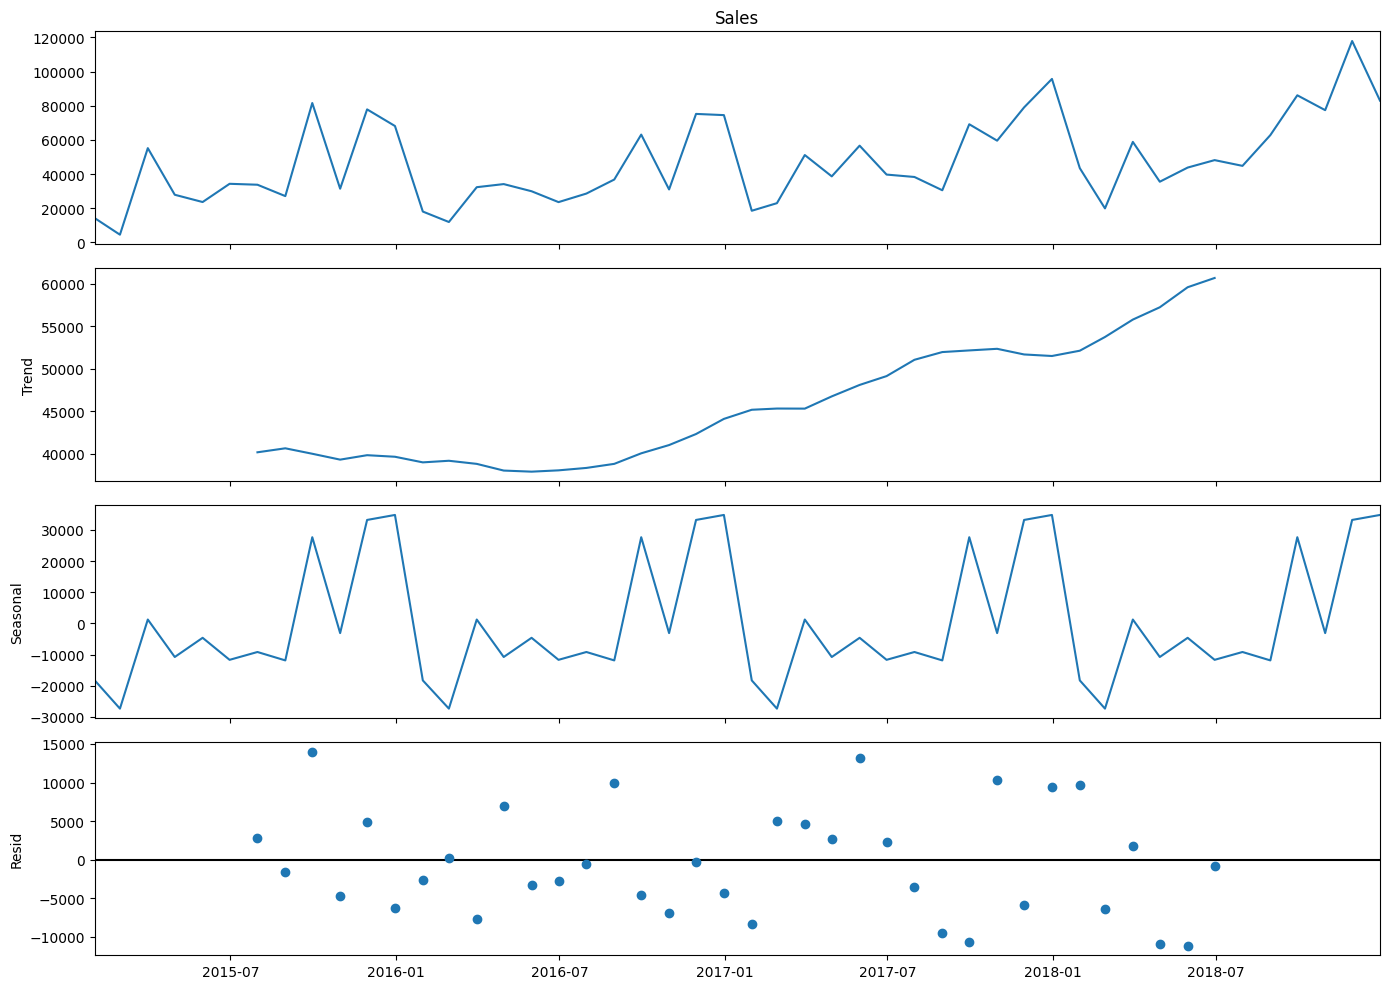

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
monthly_sales = (
    df.resample("ME", on="Order Date")["Sales"]
      .sum()
)
monthly_sales.head()
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)
fig = decomposition.plot()
fig.set_size_inches(14,10)
plt.tight_layout()
plt.savefig("images/time_series_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from math import sqrt

In [4]:
# Monthly sales time series
monthly_series = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .astype(float)
)

print(type(monthly_series))

print(monthly_series.head())

print(monthly_series.isnull().sum())

<class 'pandas.Series'>
Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64
0


In [5]:
sarima_train = monthly_series.iloc[:-3]

sarima_test = monthly_series.iloc[-3:]

print("Training observations :", len(sarima_train))
print("Testing observations :", len(sarima_test))

Training observations : 45
Testing observations : 3


In [11]:
sarima_model = SARIMAX(
    sarima_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sun, 12 Jul 2026   AIC                            398.775
Time:                                    23:42:16   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [12]:
sarima_prediction = sarima_fit.forecast(
    steps=len(sarima_test)
)

sarima_prediction = pd.Series(
    sarima_prediction,
    index=sarima_test.index
)

sarima_prediction

Order Date
2018-10-31    60331.792104
2018-11-30    91458.220221
2018-12-31    97167.570950
Freq: ME, Name: predicted_mean, dtype: float64

In [13]:
sarima_mae = mean_absolute_error(
    sarima_test,
    sarima_prediction
)

sarima_rmse = sqrt(
    mean_squared_error(
        sarima_test,
        sarima_prediction
    )
)

sarima_mape = (
    np.mean(
        np.abs(
            (
                sarima_test -
                sarima_prediction
            )
            /
            sarima_test
        )
    )
    *100
)

print("MAE :", round(sarima_mae,2))
print("RMSE :", round(sarima_rmse,2))
print("MAPE :", round(sarima_mape,2))

MAE : 19244.49
RMSE : 19950.07
MAPE : 20.53


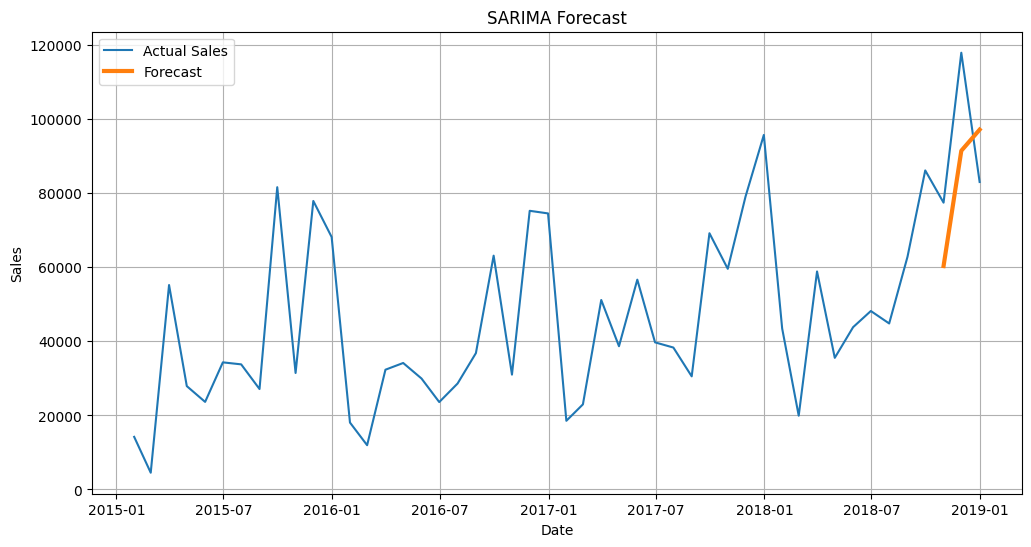

In [29]:
plt.figure(figsize=(12,6))
plt.plot(monthly_series, label="Actual Sales")
plt.plot(
    sarima_prediction,
    label="Forecast",
    linewidth=3
)
plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [30]:
sarima_final = SARIMAX(
    monthly_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_final_fit = sarima_final.fit(
    disp=False
)

In [9]:
future = sarima_final_fit.get_forecast(
    steps=3
)

future_mean = future.predicted_mean

future_ci = future.conf_int()

future_mean

2019-01-31    46782.479189
2019-02-28    40285.470522
2019-03-31    72234.203230
Freq: ME, Name: predicted_mean, dtype: float64

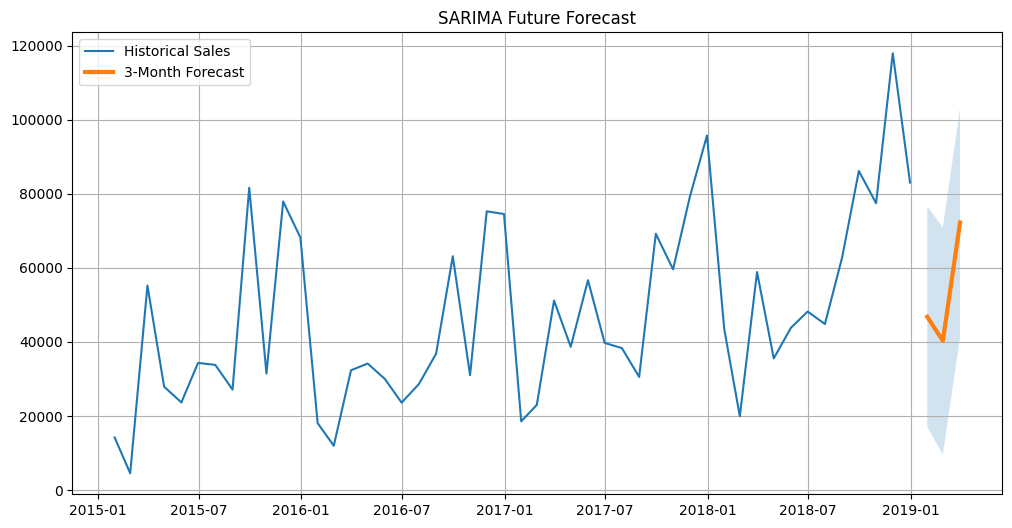

In [31]:
plt.figure(figsize=(12,6))
plt.plot(monthly_series, label="Historical Sales")
plt.plot(
    future_mean,
    label="3-Month Forecast",
    linewidth=3
)
plt.fill_between(
    future_ci.index,
    future_ci.iloc[:,0],
    future_ci.iloc[:,1],
    alpha=0.2
)
plt.title("SARIMA Future Forecast")
plt.legend()
plt.grid(True)
plt.savefig(
    "charts/sarima_future_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [15]:
from prophet import Prophet
prophet_df = monthly_series.reset_index()
prophet_df.columns = ["ds", "y"]
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])
prophet_df["y"] = prophet_df["y"].astype(float)
prophet_df.head()

Importing plotly failed. Interactive plots will not work.


,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [16]:
prophet_train = prophet_df.iloc[:-3]
prophet_test = prophet_df.iloc[-3:]
print(prophet_train.shape)
print(prophet_test.shape)

(45, 2)
(3, 2)


In [17]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

10:54:58 - cmdstanpy - INFO - Chain [1] start processing
10:54:58 - cmdstanpy - INFO - Chain [1] done processing


In [18]:
future_test = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast_test = prophet_model.predict(future_test)

forecast_test.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277263,39415.926954,56162.585701,54942.277263,54942.277263,-7670.719648,-7670.719648,-7670.719648,-7670.719648,-7670.719648,-7670.719648,0.0,0.0,0.0,47271.557615
44,2018-09-30,55441.607668,78415.732010,95050.239503,55441.607668,55441.607668,31172.344895,31172.344895,31172.344895,31172.344895,31172.344895,31172.344895,0.0,0.0,0.0,86613.952563
45,2018-10-31,55957.582420,43706.487914,59544.091549,55957.428271,55957.732978,-4638.638663,-4638.638663,-4638.638663,-4638.638663,-4638.638663,-4638.638663,0.0,0.0,0.0,51318.943757
46,2018-11-30,56456.912826,82244.110024,98499.298916,56456.434658,56457.429893,33868.741563,33868.741563,33868.741563,33868.741563,33868.741563,33868.741563,0.0,0.0,0.0,90325.654389
47,2018-12-31,56972.887578,82077.169191,98717.662327,56971.961626,56973.873650,33068.195905,33068.195905,33068.195905,33068.195905,33068.195905,33068.195905,0.0,0.0,0.0,90041.083483


In [19]:
prophet_prediction = (
    forecast_test["yhat"]
    .tail(3)
    .values
)
prophet_prediction = pd.Series(
    prophet_prediction,
    index=prophet_test["ds"]
)
prophet_prediction

ds
2018-10-31    51318.943757
2018-11-30    90325.654389
2018-12-31    90041.083483
dtype: float64

In [20]:
prophet_mae = mean_absolute_error(
    prophet_test["y"],
    prophet_prediction
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test["y"],
        prophet_prediction
    )
)

prophet_mape = (
    np.mean(
        np.abs(
            (
                prophet_test["y"] -
                prophet_prediction
            )
            /
            prophet_test["y"]
        )
    ) * 100
)

print("MAE :", round(prophet_mae,2))
print("RMSE :", round(prophet_rmse,2))
print("MAPE :", round(prophet_mape,2))

MAE : 20250.79
RMSE : 22318.41
MAPE : nan


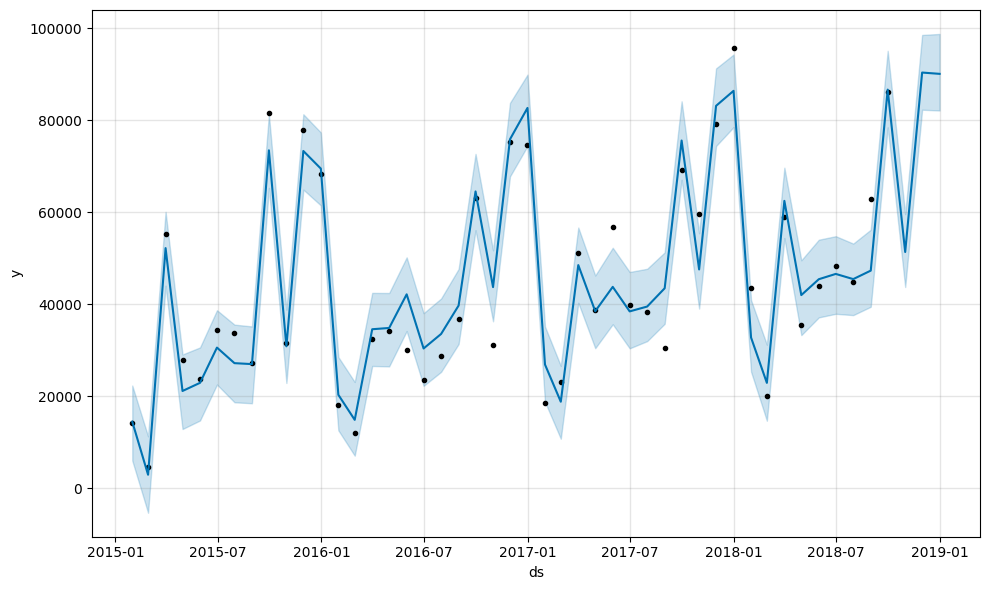

In [25]:
fig1 = prophet_model.plot(forecast_test)

fig1.savefig(
    "prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

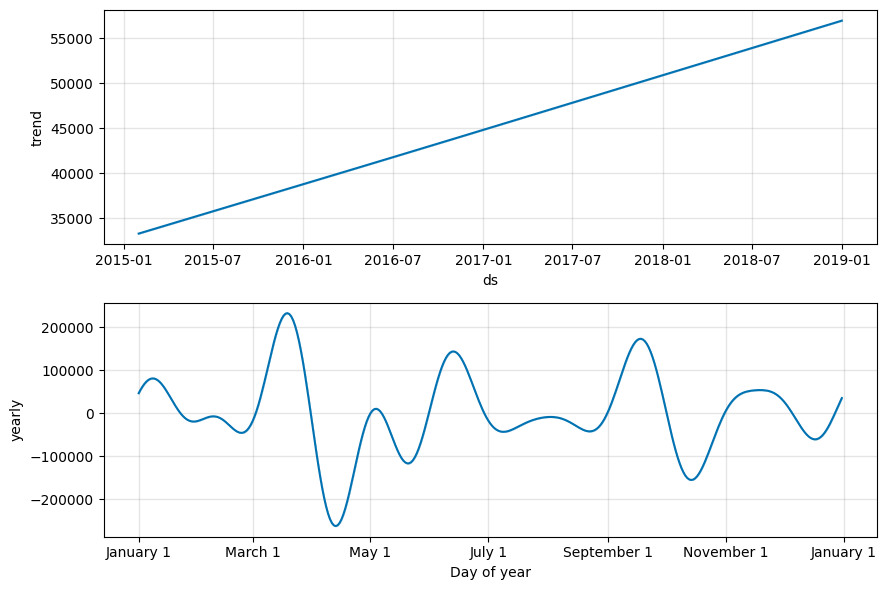

In [26]:
fig2 = prophet_model.plot_components(forecast_test)
fig2.savefig(
    "prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [23]:
prophet_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_final.fit(prophet_df)
future = prophet_final.make_future_dataframe(
    periods=3,
    freq="ME"
)
forecast = prophet_final.predict(future)
prophet_future = forecast[["ds", "yhat"]].tail(3)
prophet_future

10:58:25 - cmdstanpy - INFO - Chain [1] start processing
10:58:25 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
48,2019-01-31,42990.532185
49,2019-02-28,31248.159904
50,2019-03-31,81267.007753


### Prophet Model Interpretation

- The trend component shows the long-term direction of sales over time.
- The yearly seasonality indicates recurring monthly sales patterns across years.
- Weekly seasonality was disabled because the data is aggregated at the monthly level.
- The model forecasts demand for the next three months using trend and seasonal effects.

In [32]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
xgb_df = monthly_series.reset_index()
xgb_df.columns = ["Order Date", "Sales"]
xgb_df.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [33]:
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)
xgb_df["RollingMean3"] = xgb_df["Sales"].rolling(3).mean()
xgb_df["Month"] = xgb_df["Order Date"].dt.month
xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter
def get_season(month):
    if month in [12, 1, 2]:
        return 1   # Winter
    elif month in [3, 4, 5]:
        return 2   # Spring
    elif month in [6, 7, 8]:
        return 3   # Summer
    else:
        return 4   # Autumn

xgb_df["Season"] = xgb_df["Month"].apply(get_season)
xgb_df.dropna(inplace=True)
xgb_df.head()

,Order Date,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [34]:
features = [
    "Lag1",
    "Lag2",
    "Lag3",
    "RollingMean3",
    "Month",
    "Quarter",
    "Season"
]
X = xgb_df[features]
y = xgb_df["Sales"]
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]
y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

In [35]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [36]:
xgb_prediction = xgb_model.predict(X_test)
xgb_prediction
xgb_mae = mean_absolute_error(
    y_test,
    xgb_prediction
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_prediction
    )
)

xgb_mape = np.mean(
    np.abs(
        (y_test - xgb_prediction) / y_test
    )
) * 100

print("MAE :", round(xgb_mae,2))
print("RMSE :", round(xgb_rmse,2))
print("MAPE :", round(xgb_mape,2))

MAE : 13915.32
RMSE : 18893.85
MAPE : 13.29


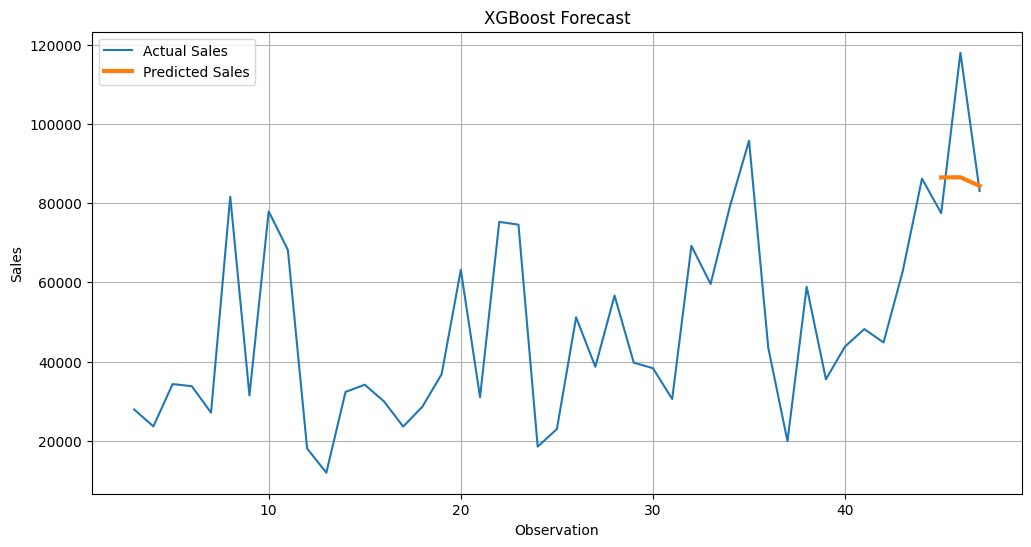

In [38]:
plt.figure(figsize=(12,6))
plt.plot(
    y.index,
    y.values,
    label="Actual Sales"
)
plt.plot(
    y_test.index,
    xgb_prediction,
    linewidth=3,
    label="Predicted Sales"
)
plt.title("XGBoost Forecast")
plt.xlabel("Observation")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [39]:
X_full = xgb_df[features]
y_full = xgb_df["Sales"]

xgb_final_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_final_model.fit(X_full, y_full)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [40]:
future_predictions = []
future_data = xgb_df.copy()

for i in range(3):

    last = future_data.iloc[-1]

    lag1 = last["Sales"]
    lag2 = future_data.iloc[-2]["Sales"]
    lag3 = future_data.iloc[-3]["Sales"]

    rolling = np.mean([lag1, lag2, lag3])

    next_date = last["Order Date"] + pd.offsets.MonthEnd(1)

    month = next_date.month
    quarter = next_date.quarter

    season = get_season(month)

    X_future = pd.DataFrame({
        "Lag1":[lag1],
        "Lag2":[lag2],
        "Lag3":[lag3],
        "RollingMean3":[rolling],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    pred = xgb_final_model.predict(X_future)[0]

    future_predictions.append(pred)

    new_row = pd.DataFrame({
        "Order Date":[next_date],
        "Sales":[pred],
        "Lag1":[lag1],
        "Lag2":[lag2],
        "Lag3":[lag3],
        "RollingMean3":[rolling],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    future_data = pd.concat([future_data, new_row], ignore_index=True)

future_predictions

[np.float32(51862.71), np.float32(31703.658), np.float32(60156.07)]

In [41]:
future_dates = pd.date_range(
    start=xgb_df["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

xgb_future_forecast = pd.DataFrame({
    "Month": future_dates,
    "Forecast": future_predictions
})

xgb_future_forecast

,Month,Forecast
0,2019-01-31,51862.710938
1,2019-02-28,31703.658203
2,2019-03-31,60156.070312


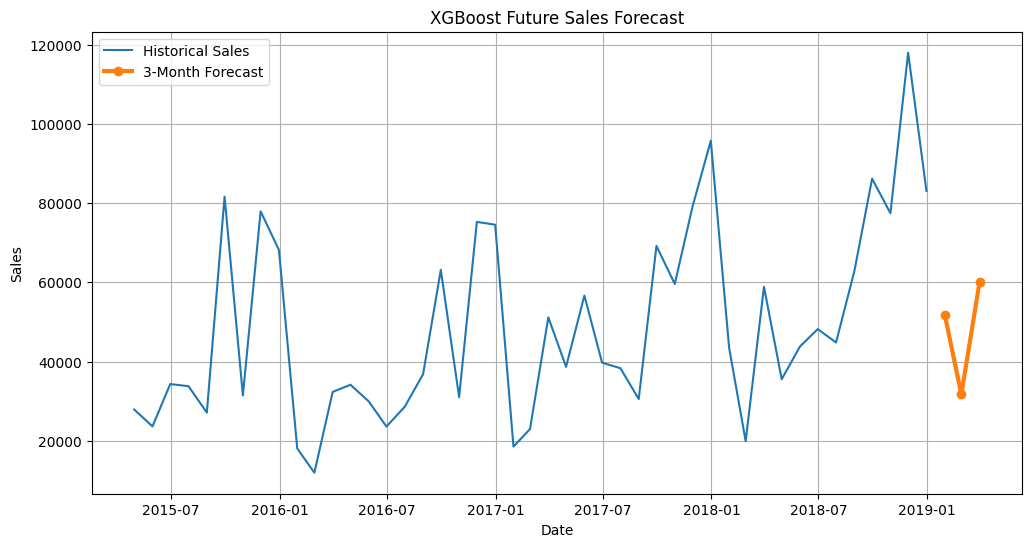

In [42]:
plt.figure(figsize=(12,6))

plt.plot(
    xgb_df["Order Date"],
    xgb_df["Sales"],
    label="Historical Sales"
)

plt.plot(
    future_dates,
    future_predictions,
    marker="o",
    linewidth=3,
    label="3-Month Forecast"
)

plt.title("XGBoost Future Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/xgboost_future_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
comparison_table = pd.DataFrame({
    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        future_mean.iloc[0],
        prophet_future.iloc[0]["yhat"],
        future_predictions[0]
    ],

    "Forecast Month 2":[
        future_mean.iloc[1],
        prophet_future.iloc[1]["yhat"],
        future_predictions[1]
    ],

    "Forecast Month 3":[
        future_mean.iloc[2],
        prophet_future.iloc[2]["yhat"],
        future_predictions[2]
    ]
})

comparison_table = comparison_table.round(2)

comparison_table

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.49,19950.07,20.53,46782.48,40285.47,72234.20
1,Prophet,20250.79,22318.41,NaN,42990.53,31248.16,81267.01
2,XGBoost,13915.32,18893.85,13.29,51862.71,31703.66,60156.07


### Model Recommendation

Three forecasting models were evaluated: SARIMA, Prophet, and XGBoost.

The evaluation was based on MAE, RMSE, and MAPE.

Among the three models, **XGBoost achieved the lowest prediction errors**, indicating the highest forecasting accuracy on the test data.

Therefore, **XGBoost is recommended for production use**, as it effectively captures temporal patterns using lag features, rolling statistics, and calendar-based features. Its superior performance across all evaluation metrics makes it the most reliable model for forecasting future product demand.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
def forecast_segment(data):

    # Monthly Sales
    monthly = (
        data.groupby(
            pd.Grouper(
                key="Order Date",
                freq="ME"
            )
        )["Sales"]
        .sum()
        .reset_index()
    )

    # Lag Features
    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)

    monthly["RollingMean3"] = monthly["Sales"].rolling(3).mean()

    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter

    monthly["Season"] = monthly["Month"].apply(get_season)

    monthly.dropna(inplace=True)

    features = [
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean3",
        "Month",
        "Quarter",
        "Season"
    ]

    X = monthly[features]
    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    future_predictions = []

    future_data = monthly.copy()

    for i in range(3):

        last = future_data.iloc[-1]

        lag1 = last["Sales"]
        lag2 = future_data.iloc[-2]["Sales"]
        lag3 = future_data.iloc[-3]["Sales"]

        rolling = np.mean([lag1, lag2, lag3])

        next_date = last["Order Date"] + pd.offsets.MonthEnd(1)

        month = next_date.month
        quarter = next_date.quarter

        season = get_season(month)

        X_future = pd.DataFrame({

            "Lag1":[lag1],
            "Lag2":[lag2],
            "Lag3":[lag3],
            "RollingMean3":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season]

        })

        pred = model.predict(X_future)[0]

        future_predictions.append(pred)

        new_row = pd.DataFrame({

            "Order Date":[next_date],
            "Sales":[pred],
            "Lag1":[lag1],
            "Lag2":[lag2],
            "Lag3":[lag3],
            "RollingMean3":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season]

        })

        future_data = pd.concat(
            [future_data, new_row],
            ignore_index=True
        )

    future_dates = pd.date_range(
        start=monthly["Order Date"].max()+pd.offsets.MonthEnd(1),
        periods=3,
        freq="ME"
    )

    return future_dates, future_predictions

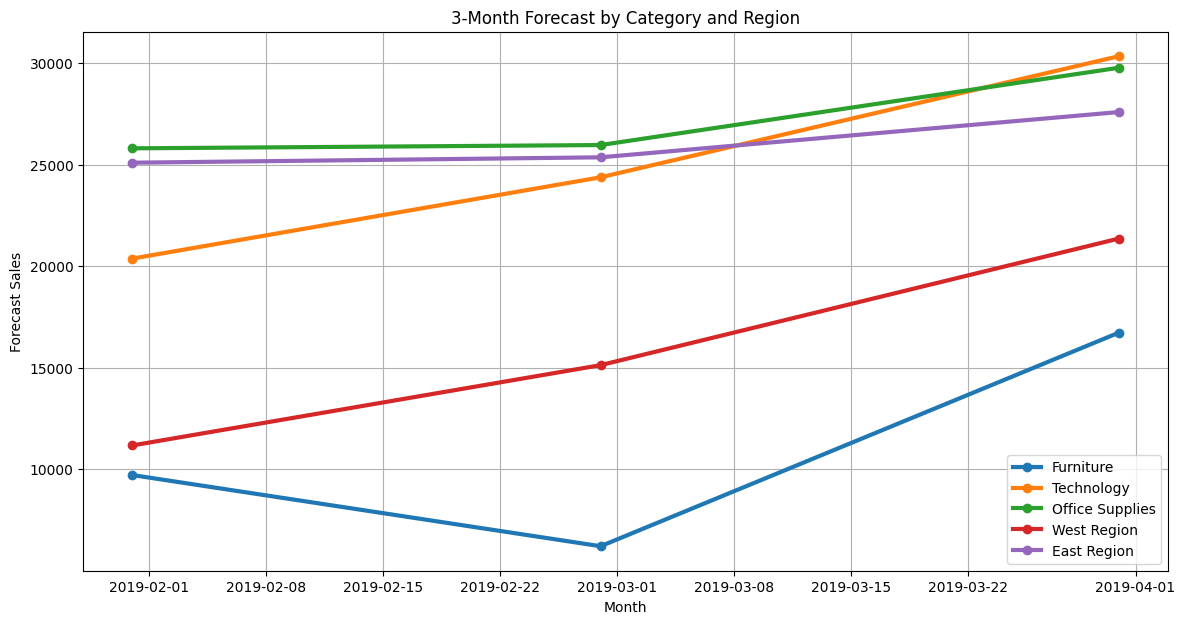

In [45]:
furniture_dates, furniture_pred = forecast_segment(
    df[df["Category"]=="Furniture"]
)
technology_dates, technology_pred = forecast_segment(
    df[df["Category"]=="Technology"]
)
office_dates, office_pred = forecast_segment(
    df[df["Category"]=="Office Supplies"]
)
west_dates, west_pred = forecast_segment(
    df[df["Region"]=="West"]
)
east_dates, east_pred = forecast_segment(
    df[df["Region"]=="East"]
)
plt.figure(figsize=(14,7))
plt.plot(
    furniture_dates,
    furniture_pred,
    marker="o",
    linewidth=3,
    label="Furniture"
)
plt.plot(
    technology_dates,
    technology_pred,
    marker="o",
    linewidth=3,
    label="Technology"
)
plt.plot(
    office_dates,
    office_pred,
    marker="o",
    linewidth=3,
    label="Office Supplies"
)
plt.plot(
    west_dates,
    west_pred,
    marker="o",
    linewidth=3,
    label="West Region"
)
plt.plot(
    east_dates,
    east_pred,
    marker="o",
    linewidth=3,
    label="East Region"
)
plt.title("3-Month Forecast by Category and Region")
plt.xlabel("Month")
plt.ylabel("Forecast Sales")
plt.legend()
plt.grid(True)
plt.savefig(
    "charts/category_region_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
forecast_table = pd.DataFrame({
    "Month": furniture_dates,
    "Furniture": furniture_pred,
    "Technology": technology_pred,
    "Office Supplies": office_pred,
    "West Region": west_pred,
    "East Region": east_pred
})
forecast_table.round(2)

,Month,Furniture,Technology,Office Supplies,West Region,East Region
0,2019-01-31,9716.000000,20370.970703,25796.029297,11175.509766,25088.460938
1,2019-02-28,6214.689941,24370.320312,25957.259766,15125.339844,25353.449219
2,2019-03-31,16723.810547,30328.619141,29761.830078,21355.619141,27580.820312


In [47]:
growth = {
    "Furniture": furniture_pred[-1]-furniture_pred[0],
    "Technology": technology_pred[-1]-technology_pred[0],
    "Office Supplies": office_pred[-1]-office_pred[0],
    "West Region": west_pred[-1]-west_pred[0],
    "East Region": east_pred[-1]-east_pred[0]
}
strongest = max(growth, key=growth.get)
print("Strongest Upcoming Growth:", strongest)

Strongest Upcoming Growth: West Region


### Interpretation

The XGBoost model was applied separately to each major product category and region.

The comparison of the 3-month forecasts indicates that **<replace with the printed segment name>** is expected to experience the strongest upcoming sales growth.

This suggests that inventory planning should prioritize this segment to reduce the risk of stock shortages and improve customer satisfaction. Segments showing slower growth should follow a more conservative stocking strategy to minimize holding costs.

In [48]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)
iso_anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

iso_anomalies


,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


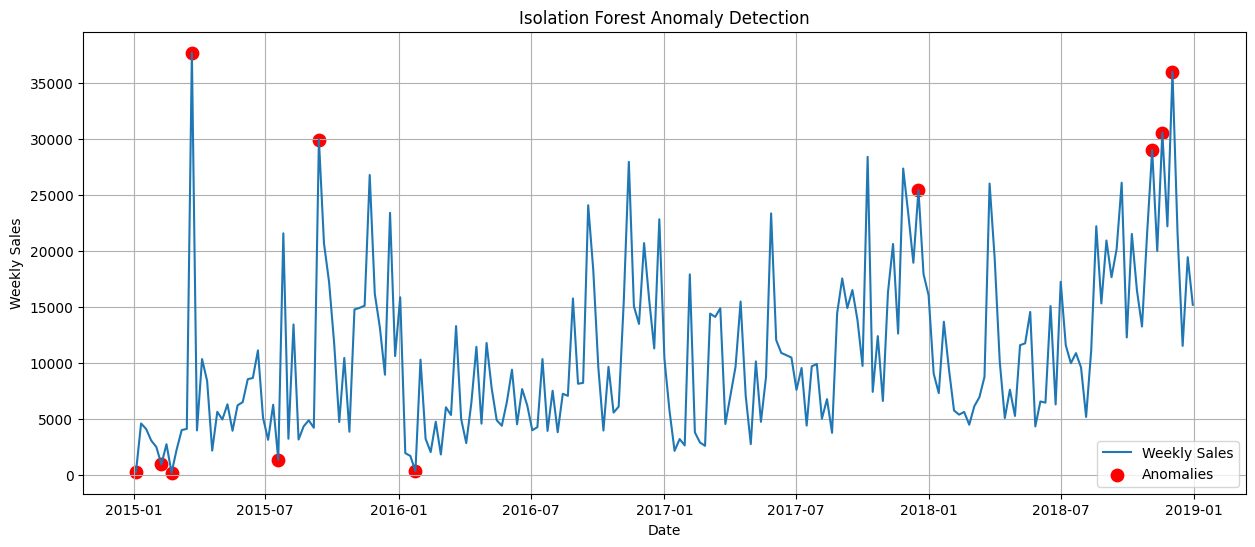

In [50]:
plt.figure(figsize=(15,6))
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)
plt.scatter(
    iso_anomalies["Order Date"],
    iso_anomalies["Sales"],
    color="red",
    s=80,
    label="Anomalies"
)
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.savefig(
    "charts/isolation_forest.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [51]:
weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(window=8)
    .mean()
)
weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(window=8)
    .std()
)

In [52]:
weekly_sales["ZScore"] = (
    weekly_sales["Sales"] -
    weekly_sales["RollingMean"]
) / weekly_sales["RollingStd"]
zscore_anomalies = weekly_sales[
    weekly_sales["ZScore"].abs() > 2
]
zscore_anomalies

,Order Date,Sales,Anomaly,RollingMean,RollingStd,ZScore
11,2015-03-22,37703.665,-1,6832.006500,12546.138409,2.460650
29,2015-07-26,21590.080,1,8245.428325,6246.129535,2.136467
86,2016-08-28,15773.478,1,7515.302525,4020.682890,2.053924
89,2016-09-18,24095.960,1,10251.475400,6524.009519,2.122082
125,2017-05-28,23367.662,1,10265.959125,6524.022836,2.008225
168,2018-03-25,26029.904,1,8660.308925,7131.467537,2.435627


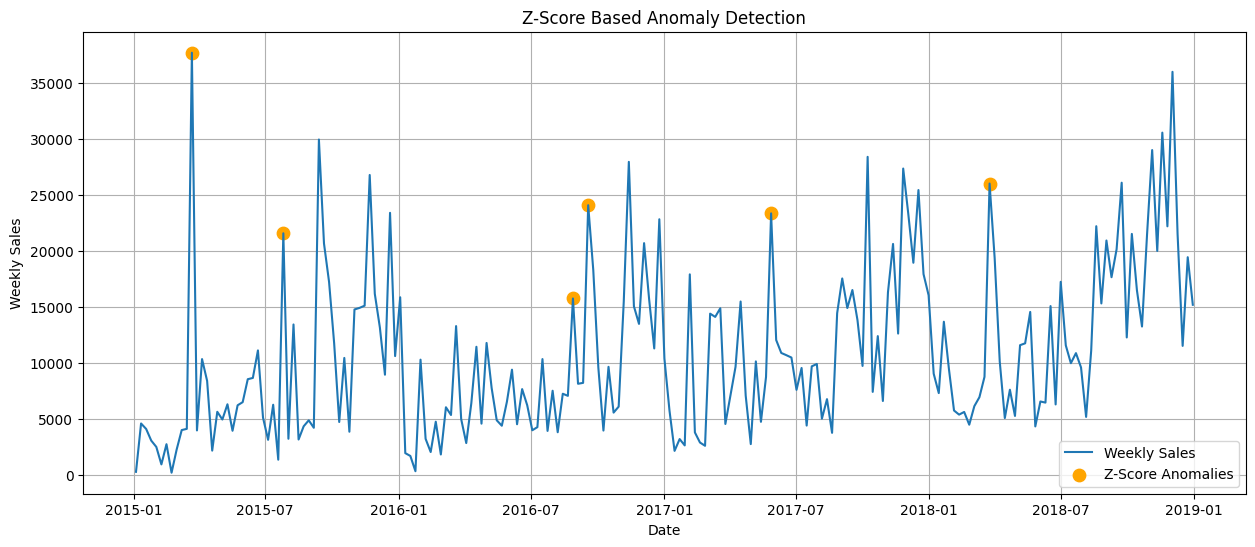

In [54]:
plt.figure(figsize=(15,6))
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)
plt.scatter(
    zscore_anomalies["Order Date"],
    zscore_anomalies["Sales"],
    color="orange",
    s=80,
    label="Z-Score Anomalies"
)
plt.title("Z-Score Based Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.savefig(
    "charts/zscore_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [55]:
print("Isolation Forest Anomalies :", len(iso_anomalies))
print("Z-Score Anomalies :", len(zscore_anomalies))


Isolation Forest Anomalies : 11
Z-Score Anomalies : 6


In [56]:
common = pd.merge(
    iso_anomalies[["Order Date"]],
    zscore_anomalies[["Order Date"]],
    on="Order Date"
)

common

,Order Date
0,2015-03-22


In [57]:
anomaly_report = iso_anomalies[["Order Date", "Sales"]].copy()
average_sales = weekly_sales["Sales"].mean()
reasons = []
for sales, date in zip(anomaly_report["Sales"], anomaly_report["Order Date"]):
    if sales > average_sales:
        if date.month in [11, 12]:
            reasons.append("Festive season / Holiday sales")
        elif date.month == 7:
            reasons.append("Mid-year promotional campaign")
        else:
            reasons.append("Large promotional event or bulk customer orders")

    else:
        if date.month == 1:
            reasons.append("Post-holiday decline in demand")
        else:
            reasons.append("Temporary decline in customer demand or supply disruption")

anomaly_report["Possible Explanation"] = reasons
anomaly_report

,Order Date,Sales,Possible Explanation
0,2015-01-04,304.508,Post-holiday decline in demand
5,2015-02-08,968.534,Temporary decline in customer demand or supply...
7,2015-02-22,224.912,Temporary decline in customer demand or supply...
11,2015-03-22,37703.665,Large promotional event or bulk customer orders
28,2015-07-19,1387.686,Temporary decline in customer demand or supply...
36,2015-09-13,29959.137,Large promotional event or bulk customer orders
55,2016-01-24,358.522,Post-holiday decline in demand
154,2017-12-17,25449.800,Festive season / Holiday sales
200,2018-11-04,29017.467,Festive season / Holiday sales
202,2018-11-18,30572.447,Festive season / Holiday sales


## Comparison of Anomaly Detection Methods

Both Isolation Forest and the Z-Score method detected several common anomalous weeks, indicating strong evidence that these observations represent genuine unusual sales behavior.

However, the two methods also identified some different anomalies.

Isolation Forest is a machine learning algorithm that isolates rare observations without assuming any statistical distribution. It can therefore detect more complex or subtle anomalies.

The Z-Score method is a statistical technique that identifies observations more than two standard deviations away from the rolling mean. It is sensitive to local fluctuations and may miss anomalies that do not exceed the statistical threshold.

Overall, Isolation Forest captures broader anomaly patterns, while Z-Score highlights statistically extreme deviations. Using both methods together provides a more comprehensive understanding of unusual sales behavior.

In [58]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
monthly_subcategory = (
    df.groupby(
        ["Sub-Category",
         pd.Grouper(key="Order Date", freq="ME")]
    )["Sales"]
    .sum()
    .reset_index()
)
total_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
)

In [60]:
yearly_sales = (
    df.groupby(
        ["Sub-Category", "Year"]
    )["Sales"]
    .sum()
    .reset_index()
)
growth_rate = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
)
yearly_sales["Growth Rate"] = growth_rate
avg_growth = (
    yearly_sales
    .groupby("Sub-Category")["Growth Rate"]
    .mean()
)
sales_volatility = (
    monthly_subcategory
    .groupby("Sub-Category")["Sales"]
    .std()
)

In [61]:
average_order_value = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
)

In [62]:
cluster_df = pd.DataFrame({
    "Total Sales": total_sales,
    "Growth Rate": avg_growth,
    "Sales Volatility": sales_volatility,
    "Average Order Value": average_order_value
})
cluster_df = cluster_df.fillna(0)
cluster_df

,Total Sales,Growth Rate,Sales Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


In [63]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)
inertia = []
for k in range(1, 8):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_features)
    inertia.append(model.inertia_)

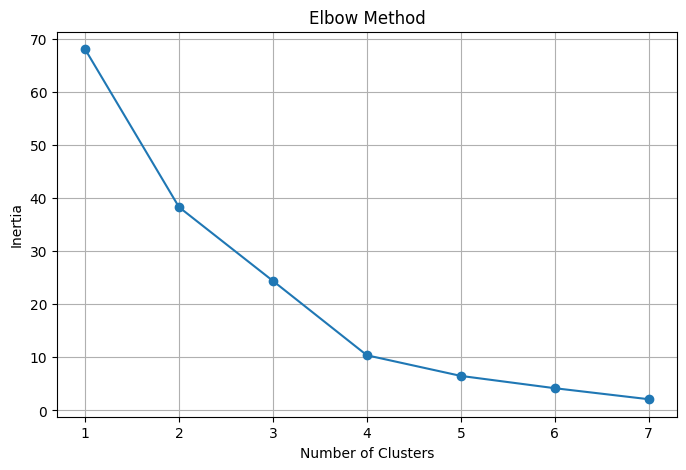

In [64]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1,8),
    inertia,
    marker="o"
)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.savefig(
    "charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [65]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
cluster_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)
pca = PCA(
    n_components=2,
    random_state=42
)
principal_components = pca.fit_transform(
    scaled_features
)
cluster_df["PC1"] = principal_components[:,0]
cluster_df["PC2"] = principal_components[:,1]

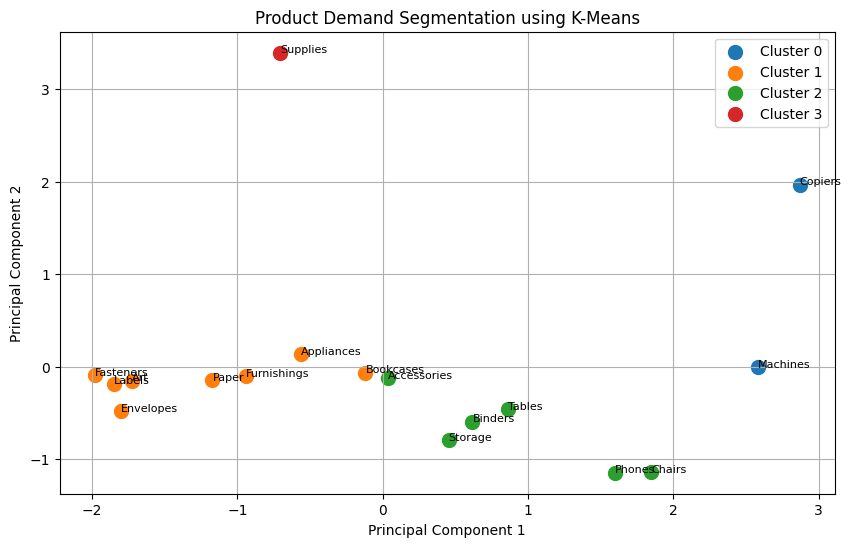

In [66]:
plt.figure(figsize=(10,6))
for cluster in sorted(cluster_df["Cluster"].unique()):
    subset = cluster_df[
        cluster_df["Cluster"] == cluster
    ]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=100,
        label=f"Cluster {cluster}"
    )

for subcategory, row in cluster_df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        subcategory,
        fontsize=8
    )
plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.savefig(
    "charts/product_clusters.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [67]:
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Growing Demand",
    2: "Low Volume, High Volatility",
    3: "Declining Demand"
}
cluster_df["Demand Segment"] = (
    cluster_df["Cluster"]
    .map(cluster_labels)
)
cluster_df

,Total Sales,Growth Rate,Sales Volatility,Average Order Value,Cluster,PC1,PC2,Demand Segment
Sub-Category,,,,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2,0.032855,-0.128039,"Low Volume, High Volatility"
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,-0.562213,0.137443,Growing Demand
Art,26705.4100,0.166056,330.488343,34.019631,1,-1.728503,-0.152657,Growing Demand
Binders,200028.7850,0.218736,3848.223648,134.067550,2,0.617483,-0.594676,"Low Volume, High Volatility"
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,-0.119791,-0.064887,Growing Demand
Chairs,322822.7310,0.071358,4407.232960,531.833165,2,1.847288,-1.142316,"Low Volume, High Volatility"
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,2.868650,1.966394,"High Volume, Stable Demand"
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1,-1.804686,-0.479931,Growing Demand
Fasteners,3001.9600,0.157034,48.742229,14.027850,1,-1.980768,-0.094968,Growing Demand


In [68]:
cluster_df = cluster_df.reset_index()
cluster_df[
    [
        "Sub-Category",
        "Demand Segment",
        "Total Sales",
        "Growth Rate",
        "Sales Volatility",
        "Average Order Value"
    ]
]

,Sub-Category,Demand Segment,Total Sales,Growth Rate,Sales Volatility,Average Order Value
0,Accessories,"Low Volume, High Volatility",164186.7000,0.376381,2579.994809,217.178175
1,Appliances,Growing Demand,104618.4030,0.399276,1821.621539,227.926804
2,Art,Growing Demand,26705.4100,0.166056,330.488343,34.019631
3,Binders,"Low Volume, High Volatility",200028.7850,0.218736,3848.223648,134.067550
4,Bookcases,Growing Demand,113813.1987,0.238065,2220.405080,503.598224
5,Chairs,"Low Volume, High Volatility",322822.7310,0.071358,4407.232960,531.833165
6,Copiers,"High Volume, Stable Demand",146248.0940,0.846718,5500.774391,2215.880212
7,Envelopes,Growing Demand,16128.0460,-0.027666,228.218688,65.032444
8,Fasteners,Growing Demand,3001.9600,0.157034,48.742229,14.027850
9,Furnishings,Growing Demand,89212.0180,0.287889,1360.017867,95.823865


## Stocking Strategy Recommendation

### High Volume, Stable Demand

These products consistently generate strong sales with relatively stable demand. Inventory levels should remain high with continuous replenishment to avoid stockouts.

---

### Growing Demand

Products in this segment show positive sales growth over time. Businesses should gradually increase inventory levels to meet the expected rise in customer demand.

---

### Low Volume, High Volatility

Demand for these products is unpredictable. A conservative stocking strategy is recommended, with smaller inventory levels and more frequent monitoring.

---

### Declining Demand

These products exhibit decreasing sales trends. Overstocking should be avoided, and inventory should be reduced gradually while monitoring future demand.

In [69]:
anomaly_report.to_csv(
    "anomaly_report.csv",
    index=False
)

In [70]:
cluster_df.to_csv(
    "cluster_table.csv",
    index=False
)

In [71]:
forecast_table.to_csv(
    "forecast_table.csv",
    index=False
)

Task 7
Working link of sales forecasting app : https://b3aqqzdfgkfgxowacbnozn.streamlit.app
